First coembedding

In [ ]:
from coembedding.function import co_embedding
import numpy as np
import scanpy as sc
import pandas as pd
import datatable as dt
import math
import os
import seaborn as sns

In [38]:
DataDir="./data/Exseq/"
sc_file_path = DataDir+'scRNA.h5ad'
RNA_data_adata = sc.read_h5ad(sc_file_path)
Spatial_file = DataDir + 'Insitu_count.txt'
location_file = DataDir + 'Locations.txt'

Spatial_data_adata = sc.read(Spatial_file, sep = '\t')
locations = pd.read_csv(location_file,sep='\t')
Spatial_data_adata.obs=locations

AnnData object with n_obs × n_vars = 524 × 1000
    obs: 'X', 'Y'
           X        Y
0    1632.02 -1305.70
1    1589.47  -669.51
2    1539.89 -1185.90
3    1513.94  -710.24
4    1477.85  -763.87
..       ...      ...
519  5980.97   308.12
520  5931.57  1141.04
521  5921.07   981.40
522  5899.27   382.42
523  9412.00   119.62

[524 rows x 2 columns]


In [39]:
X = Spatial_data_adata.obsm['locations'][:, 0]
Y = Spatial_data_adata.obsm['locations'][:, 1]
Spatial_data_adata.obs['X'] = X
Spatial_data_adata.obs['Y'] = Y

KeyError: 'locations'

2026-03-16 15:31:37,750 - root - INFO - Raw dataset shape: (14773, 1000)
2026-03-16 15:31:37,750 - root - INFO - Raw dataset shape: (14773, 1000)
2026-03-16 15:31:37,753 - root - INFO - Preprocessing
2026-03-16 15:31:37,753 - root - INFO - Preprocessing
2026-03-16 15:31:38,216 - root - INFO - Filtering cells
2026-03-16 15:31:38,216 - root - INFO - Filtering cells
2026-03-16 15:31:38,544 - root - INFO - Filtering features
2026-03-16 15:31:38,544 - root - INFO - Filtering features
2026-03-16 15:31:38,703 - root - INFO - Normalizing total per cell
2026-03-16 15:31:38,703 - root - INFO - Normalizing total per cell
2026-03-16 15:31:38,764 - root - INFO - Log1p transforming
2026-03-16 15:31:38,764 - root - INFO - Log1p transforming
2026-03-16 15:31:38,921 - root - INFO - Finding variable features
2026-03-16 15:31:38,921 - root - INFO - Finding variable features
2026-03-16 15:31:39,532 - root - INFO - Batch specific maxabs scaling
2026-03-16 15:31:39,532 - root - INFO - Batch specific maxabs 

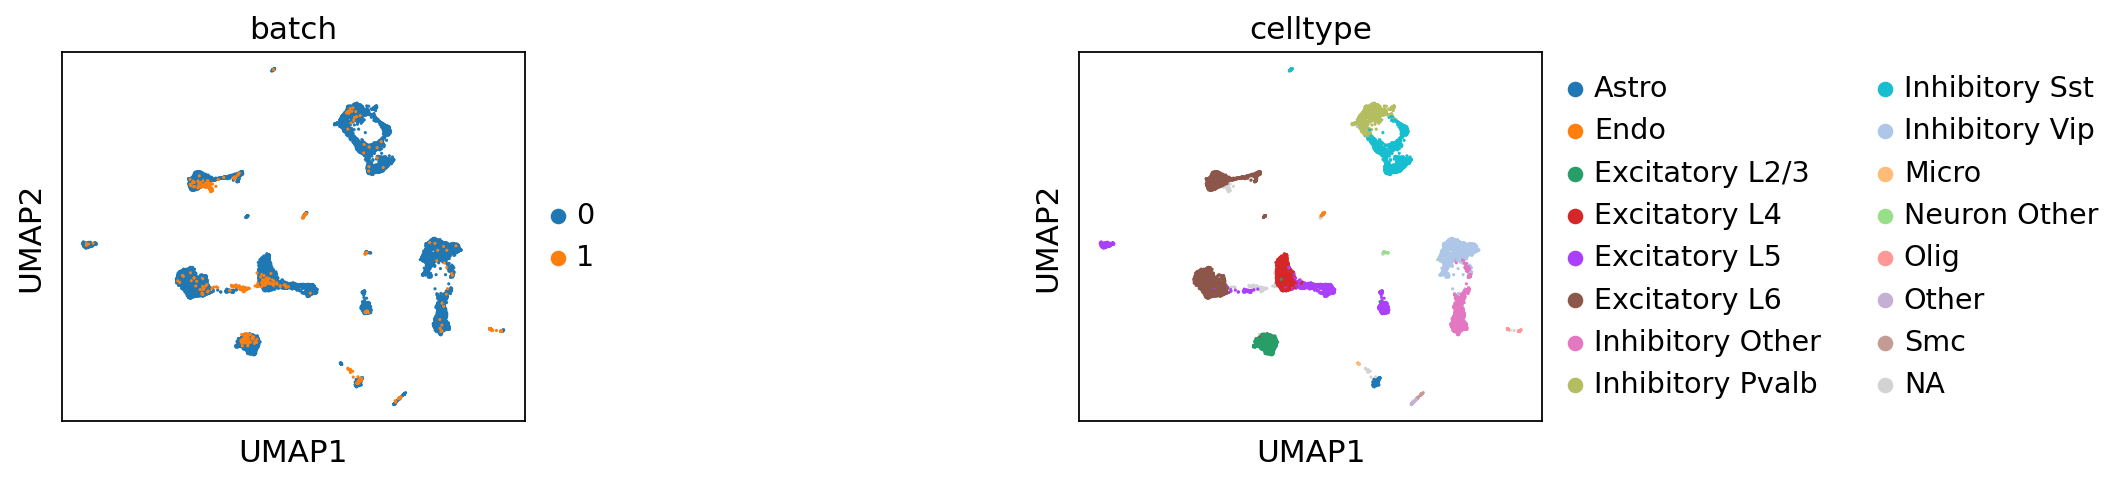

In [16]:
adata = co_embedding(data_list=[RNA_data_adata,Spatial_data_adata],outdir=DataDir)
adata_path=DataDir+"simulate_co_adata8.h5ad"
adata.write(adata_path)
# 意图是使用co_embedding函数进行数据共嵌入，并保存到simulate_co_adata.h5ad文件，不应该注释掉

In the second step, the co-embedded single-cell data and idling data are separated, and 'latent' represents the feature output by the encoder

In [17]:
adata_path=DataDir+"simulate_co_adata8.h5ad"
adata.write(adata_path)

In [40]:
co_adata=sc.read_h5ad(DataDir+'simulate_co_adata8.h5ad')
df_id = co_adata.obs['celltype']
co_adata.obs.insert(0,'celltype_final',df_id)
co_adata.obs=co_adata.obs.rename(columns={'X':'x','Y':'y'})
print(co_adata)

AnnData object with n_obs × n_vars = 14773 × 1000
    obs: 'celltype_final', 'celltype', 'x', 'y', 'batch', 'n_genes'
    var: 'n_cells'
    uns: 'batch_colors', 'celltype_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_umap', 'latent'
    obsp: 'connectivities', 'distances'


In [41]:
sc_data=co_adata[co_adata.obs['batch']=="0"]
st_data=co_adata[co_adata.obs['batch']=="1"]
print(sc_data)
print(st_data)
celltype_counts = sc_data.obs['celltype'].value_counts()
print(len(celltype_counts)) 

View of AnnData object with n_obs × n_vars = 14249 × 1000
    obs: 'celltype_final', 'celltype', 'x', 'y', 'batch', 'n_genes'
    var: 'n_cells'
    uns: 'batch_colors', 'celltype_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_umap', 'latent'
    obsp: 'connectivities', 'distances'
View of AnnData object with n_obs × n_vars = 524 × 1000
    obs: 'celltype_final', 'celltype', 'x', 'y', 'batch', 'n_genes'
    var: 'n_cells'
    uns: 'batch_colors', 'celltype_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_umap', 'latent'
    obsp: 'connectivities', 'distances'
15


According to the coordinate position of the ST data, use the K nearest neighbor regression algorithm to infer the possible coordinate position of each cell in the single-cell data

                       celltype_final          celltype   x   y batch  n_genes
F1S4_160108_001_A01    Inhibitory Vip    Inhibitory Vip NaN NaN     0      640
F1S4_160108_001_B01  Inhibitory Other  Inhibitory Other NaN NaN     0      649
F1S4_160108_001_C01  Inhibitory Other  Inhibitory Other NaN NaN     0      704
F1S4_160108_001_D01    Inhibitory Vip    Inhibitory Vip NaN NaN     0      651
F1S4_160108_001_E01  Inhibitory Other  Inhibitory Other NaN NaN     0      580
...                               ...               ...  ..  ..   ...      ...
FYS4_171004_104_C01     Excitatory L5     Excitatory L5 NaN NaN     0      670
FYS4_171004_104_D01    Inhibitory Sst    Inhibitory Sst NaN NaN     0      514
FYS4_171004_104_F01     Excitatory L5     Excitatory L5 NaN NaN     0      485
FYS4_171004_104_G01    Inhibitory Sst    Inhibitory Sst NaN NaN     0      583
FYS4_171004_104_H01  Inhibitory Pvalb  Inhibitory Pvalb NaN NaN     0      484

[14249 rows x 6 columns]


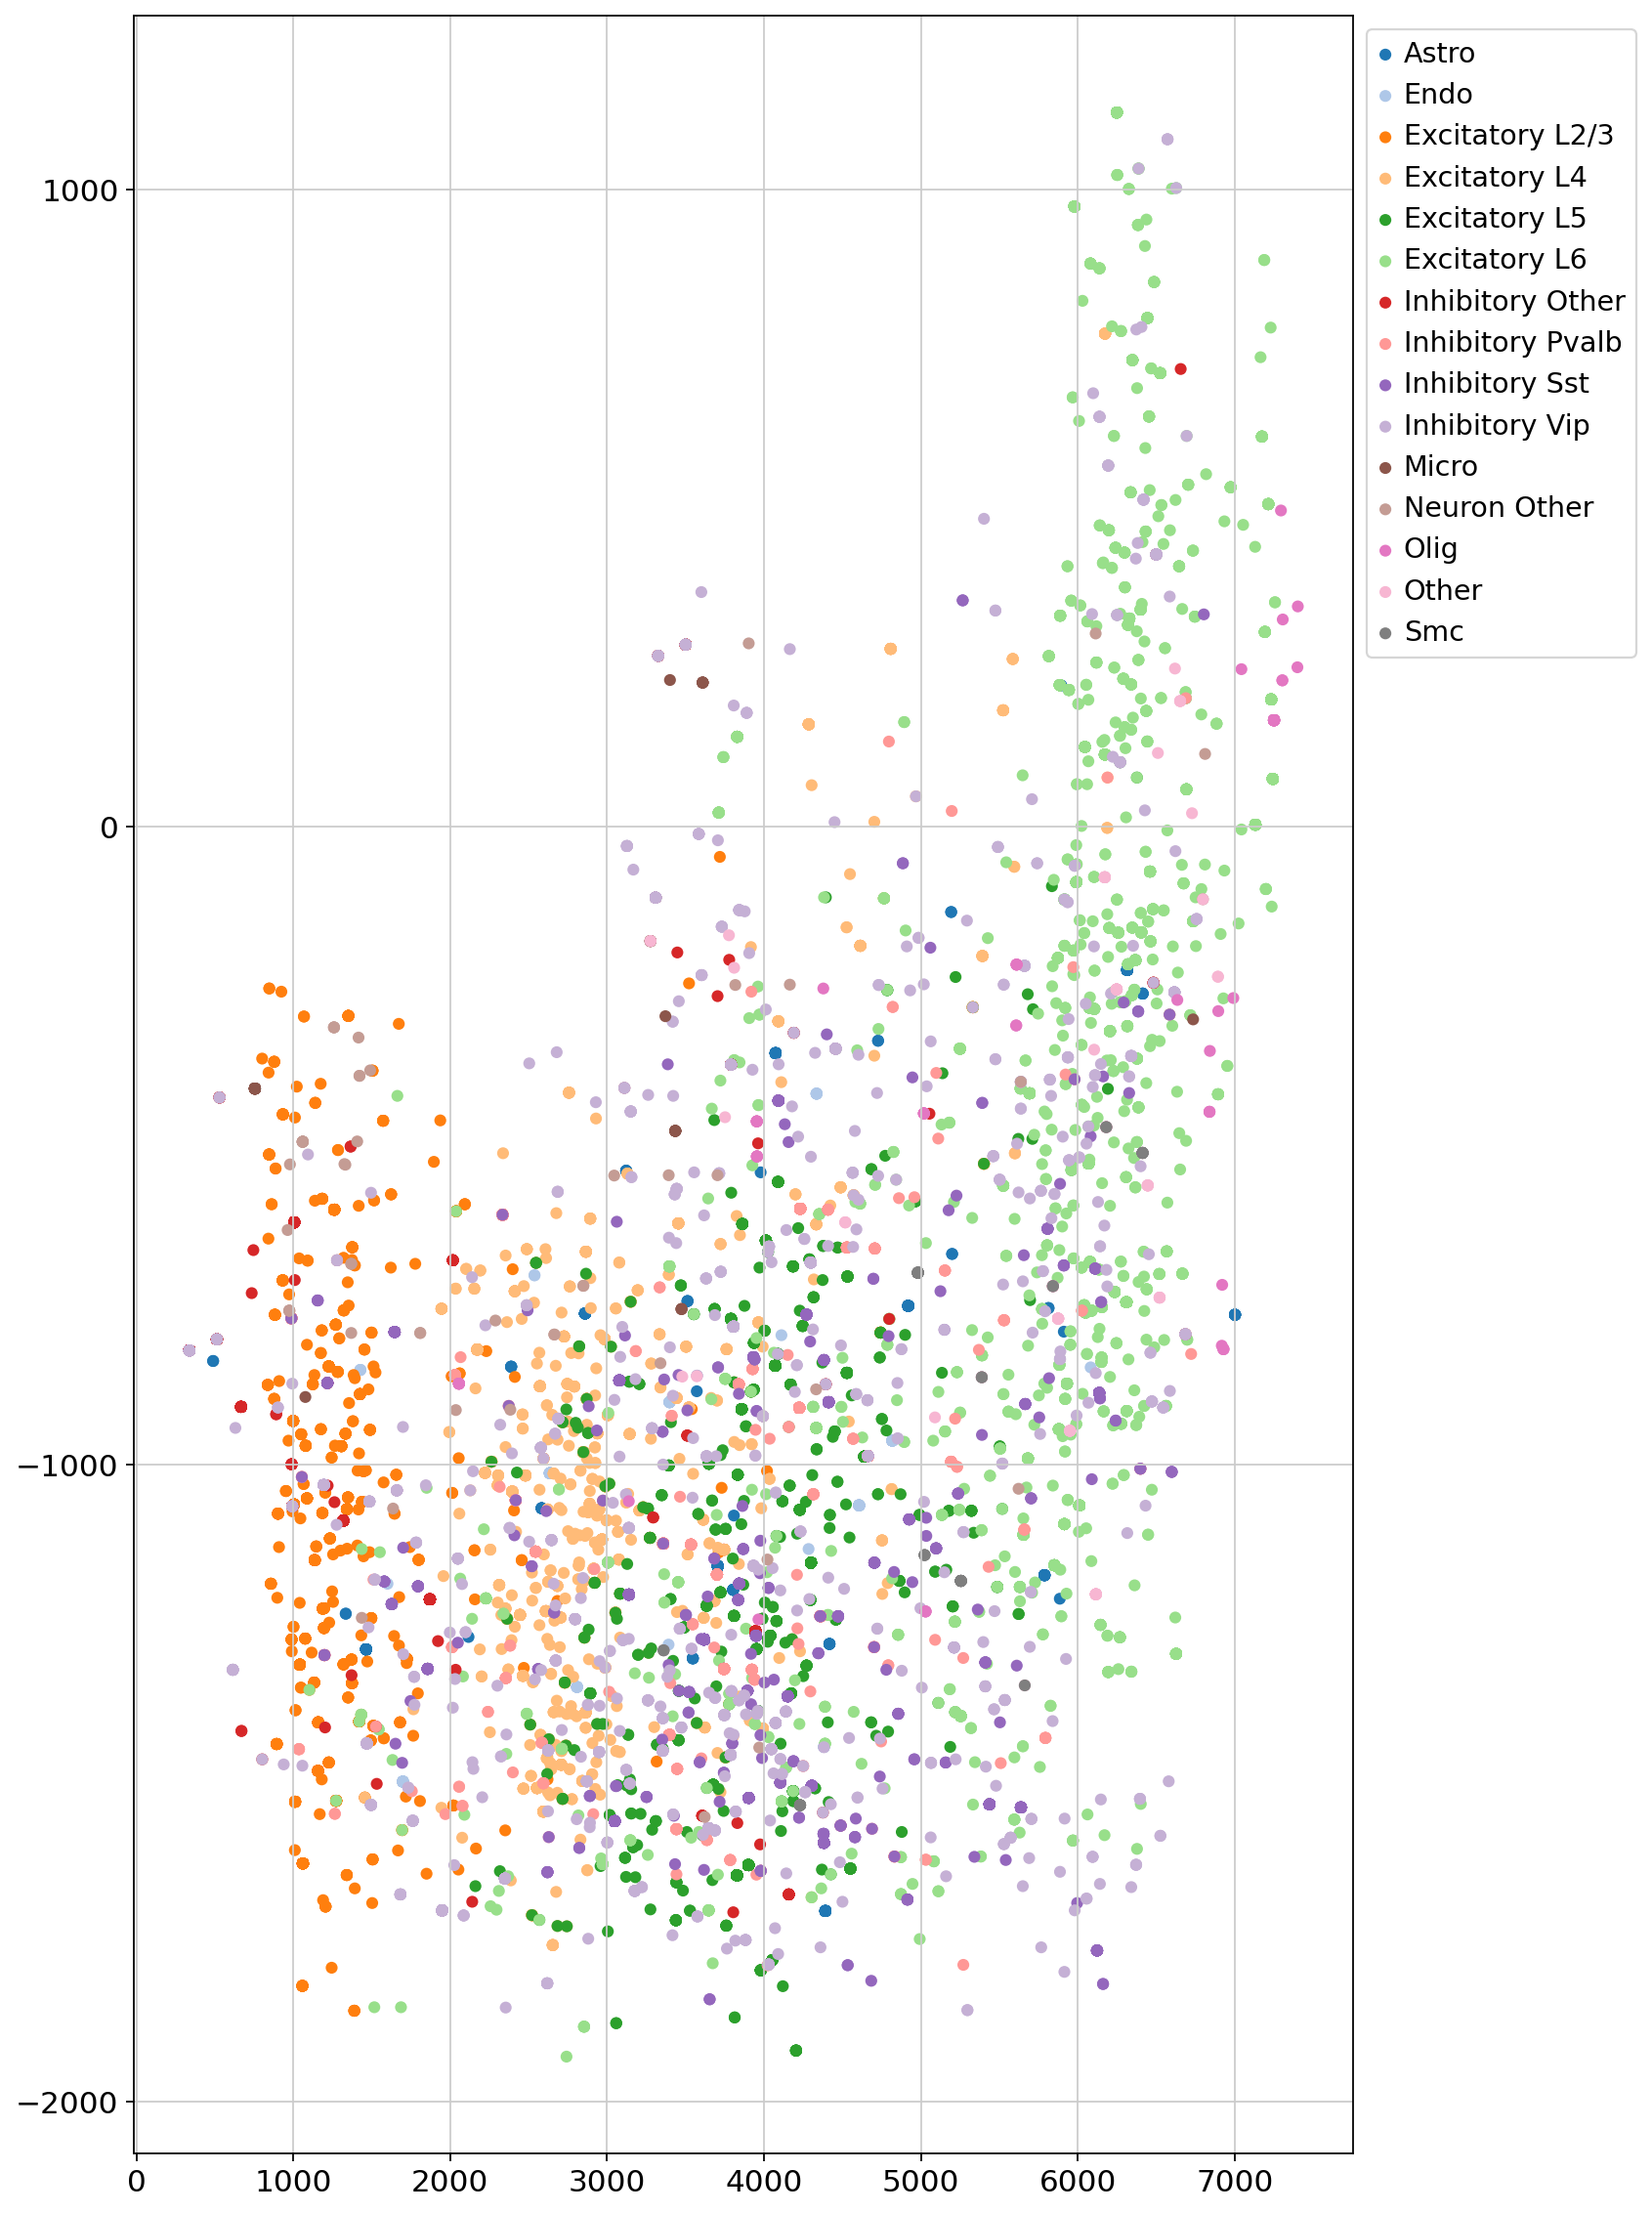

In [42]:
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

sc_meta=sc_data.obs.copy()
print(sc_meta)

X_train1=st_data.obsm['latent']
y_train1=np.array(st_data.obs[["x","y"]]).astype("int") 
X_test1=sc_data.obsm['latent']
knn = KNeighborsRegressor(n_neighbors=2).fit(X_train1, y_train1)
y_test1 = knn.predict(X_test1)

sc_meta["x"]=y_test1[:,0]
sc_meta["y"]=y_test1[:,1]

fig,ax = plt.subplots(figsize=(10,18))
cmap = sns.color_palette('tab20',n_colors=len(np.unique(np.array(sc_meta.celltype))))
for i,c in enumerate(np.unique(sc_meta.celltype_final)):
    ax.scatter(x=sc_meta[sc_meta['celltype_final'] == c]['x'],y=sc_meta[sc_meta['celltype_final'] == c]['y'],
               c=matplotlib.colors.to_hex(cmap[i]),label=c,s=30,marker='o',edgecolors='none')
ax.legend(bbox_to_anchor=(1,1))
plt.yticks(np.arange(-2000,2000,1000))
plt.xticks(np.arange(0,8000,1000))
plot_file = os.path.join(DataDir+"raw_simu_1.pdf")
fig.savefig(plot_file,dpi=600,bbox_inches = "tight")
plt.show()

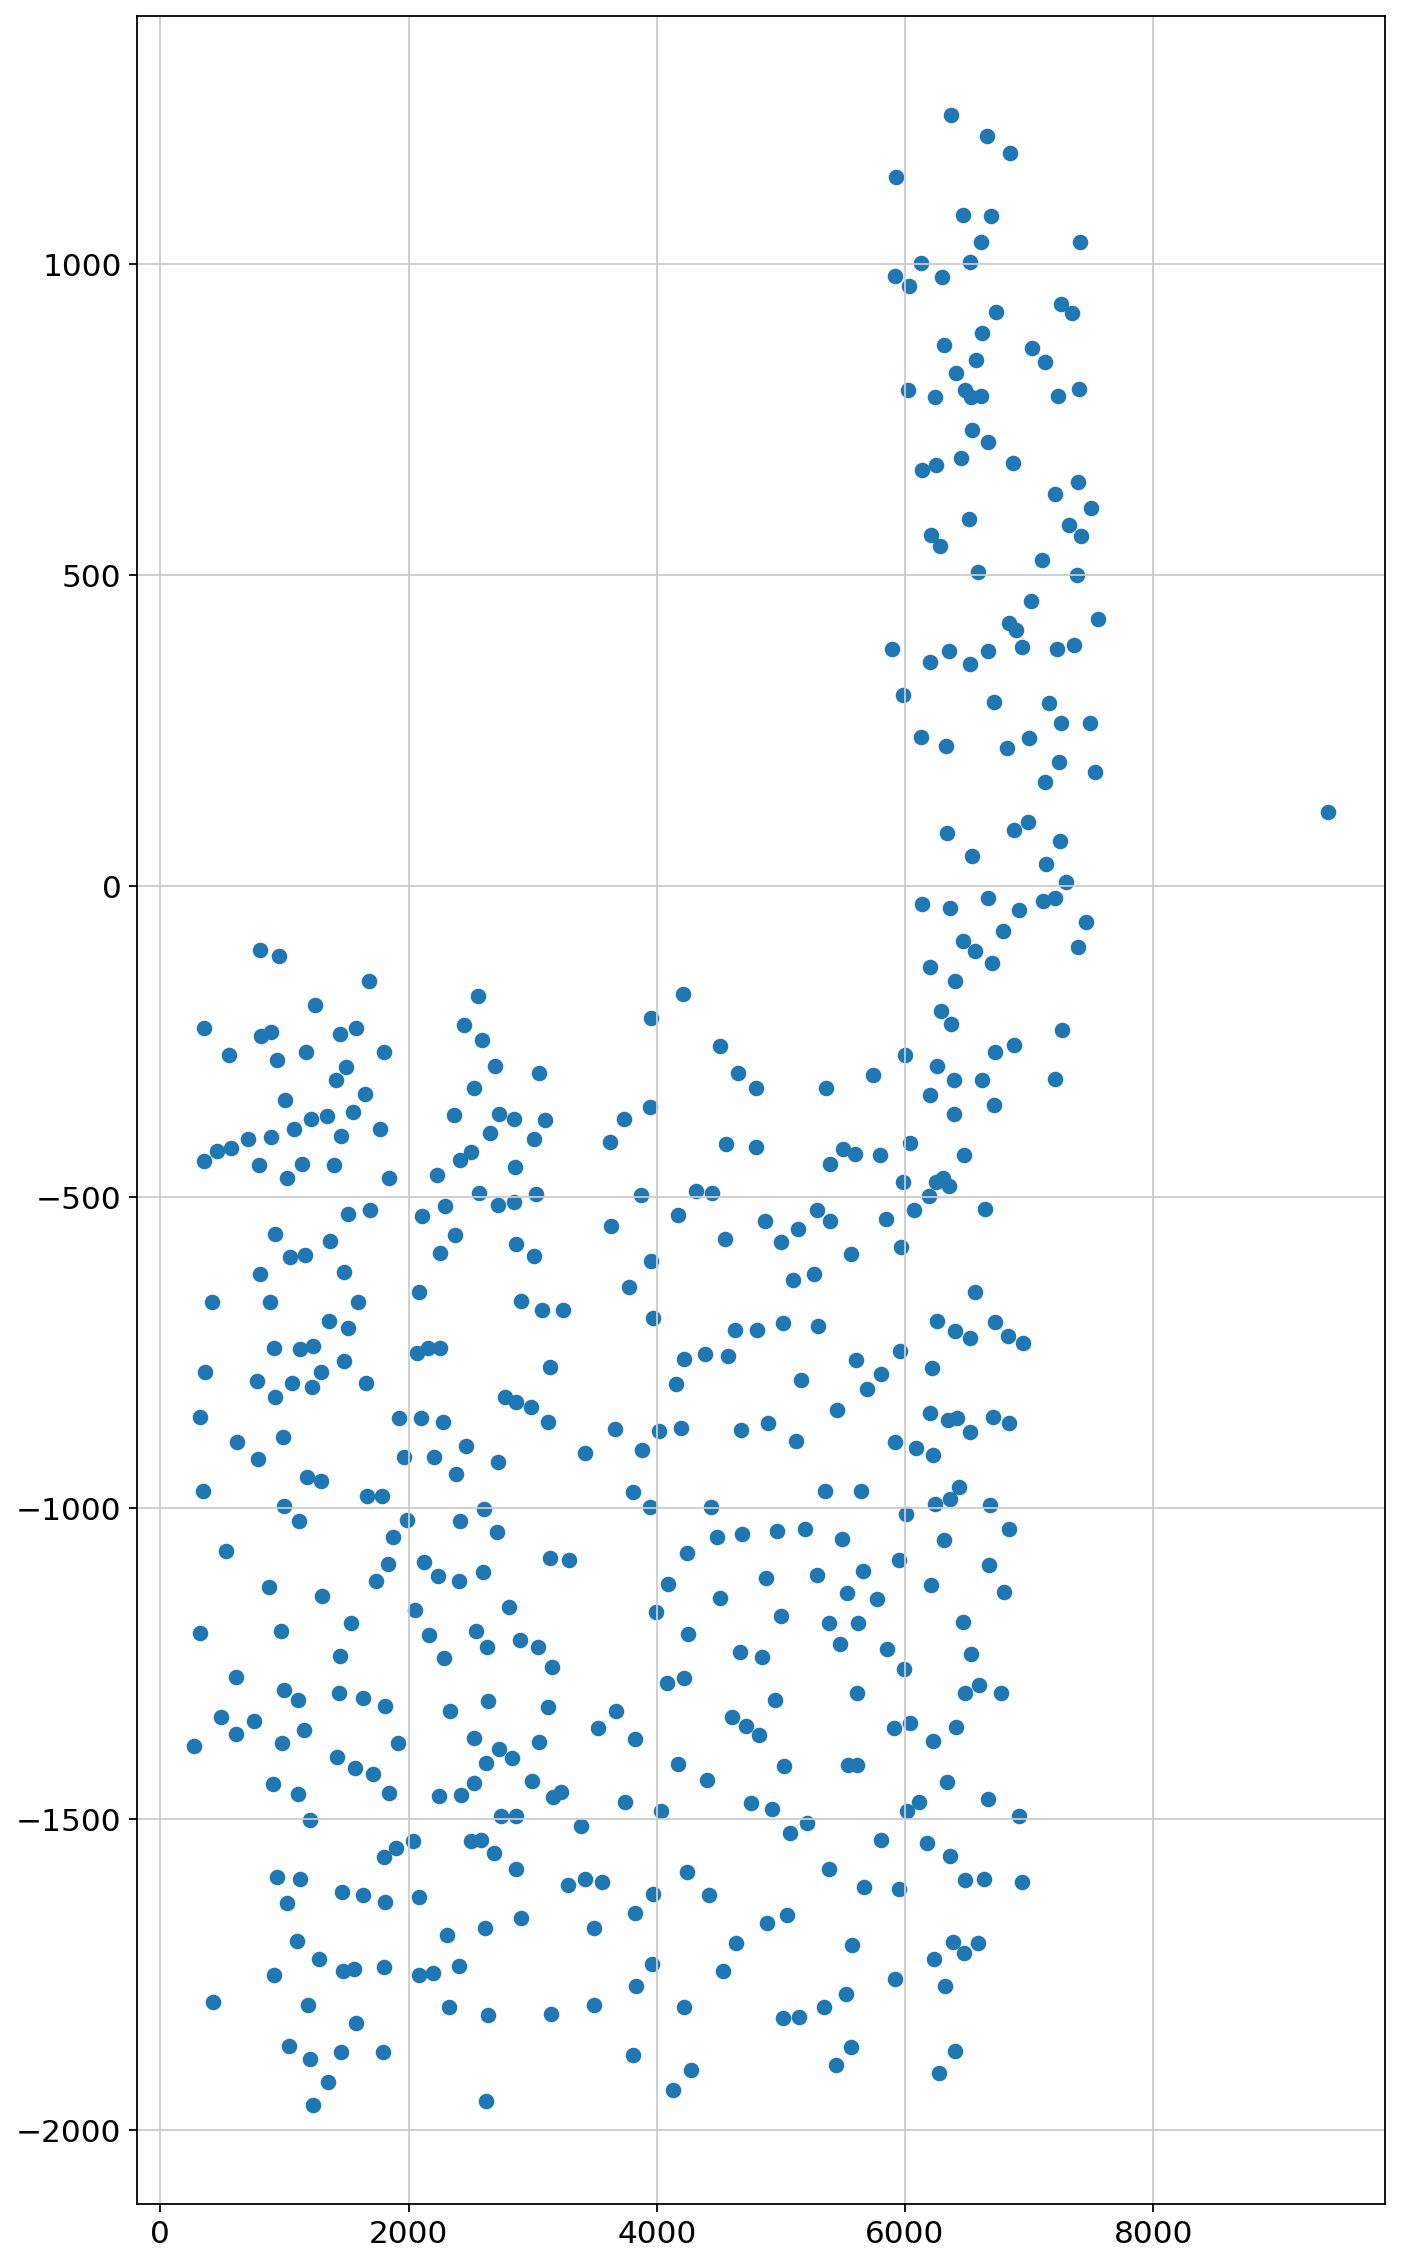

In [43]:
fig,ax = plt.subplots(figsize=(10,18))
ax.scatter(x=y_train1[:,0],y=y_train1[:,1])
plt.show()

To simulate idling data with single-cell data with coordinates, use honeycomb hexagonal spots

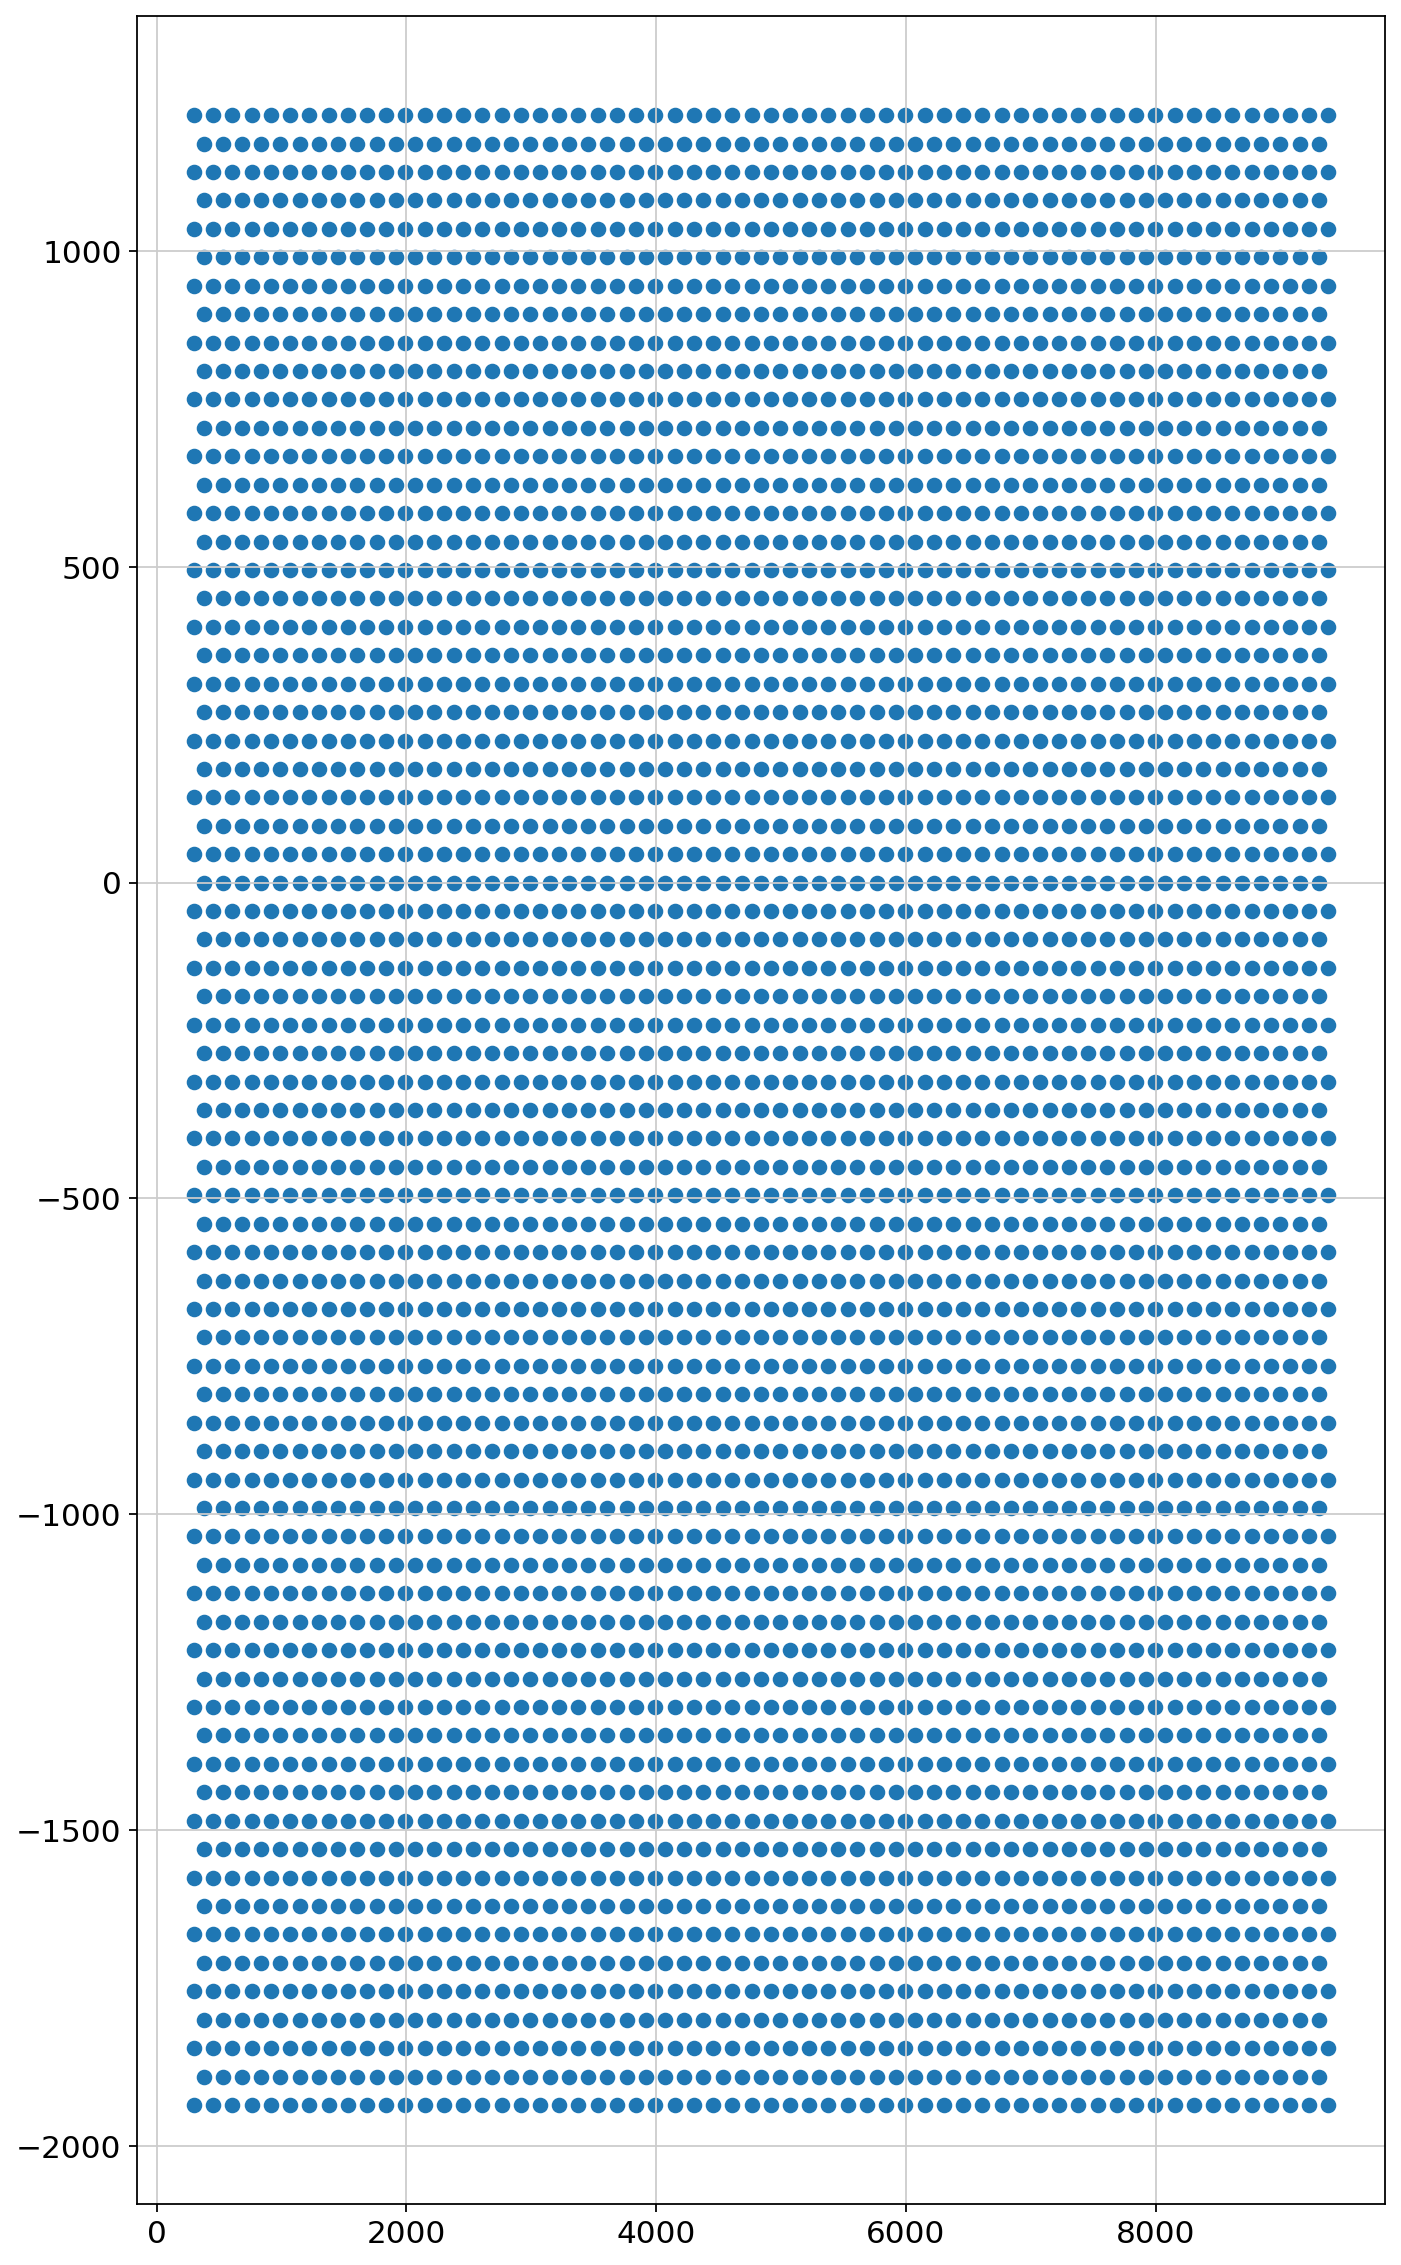

In [44]:
import math

x=y_train1[:,0]
y=y_train1[:,1]
ori_xy=[(min(x)+max(x))/2,(min(y)+max(y))/2]
height=90
trans=[[0,height],[int(height*math.sqrt(3)/2),height/2],[int(height*math.sqrt(3)/2),-height/2],
       [0,-height],[-int(height*math.sqrt(3)/2),-height/2],[-int(height*math.sqrt(3)/2),height/2]]

xy=[ori_xy]
do_ceter=0
for k,pos1 in enumerate(xy):
    if k>=do_ceter:
        do_ceter=k
        for i in range(len(trans)):
                xn=pos1[0]+trans[i][0]
                yn=pos1[1]+trans[i][1]
                if xn>=min(x) and xn<=max(x) and yn>=min(y) and yn<=max(y):
                        if [xn,yn] not in xy:
                                xy.append([xn,yn])
xy=np.array(xy)
fig,ax = plt.subplots(figsize=(10,18))
ax.scatter(x=xy[:,0],y=xy[:,1])
plt.show()

(14249, 2)


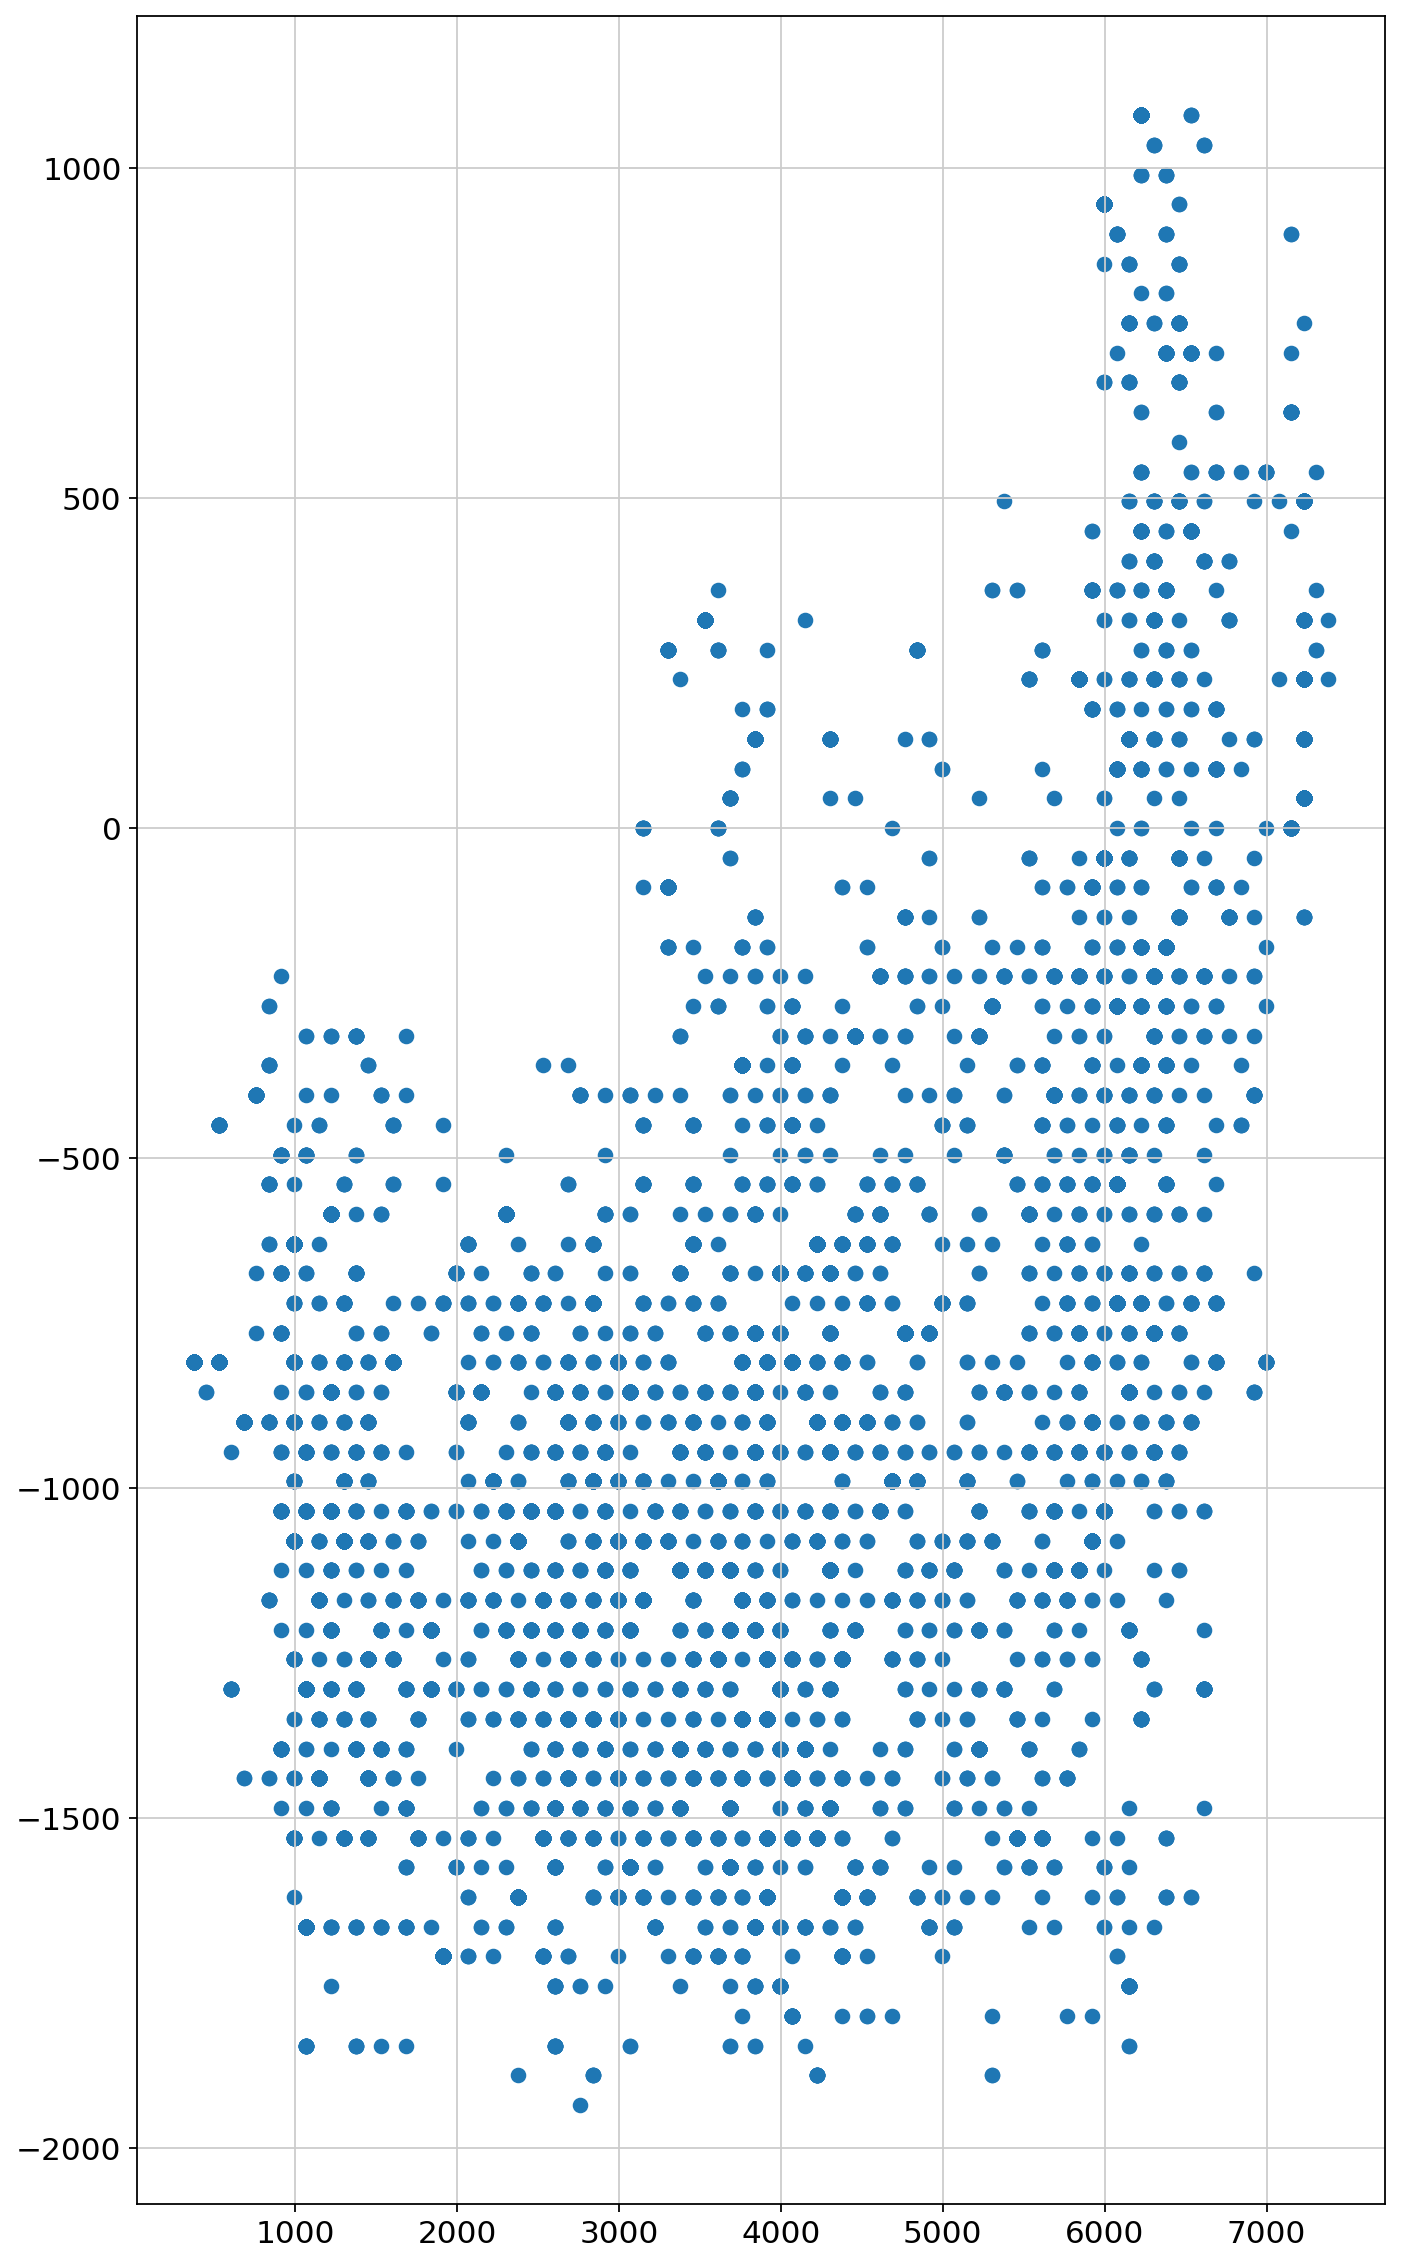

In [45]:
from sklearn.neighbors import KNeighborsClassifier
X_train2=xy
X_test2=y_test1
knn = knn = KNeighborsClassifier(n_neighbors=1).fit(X_train2,X_train2.astype("int"))
y_test2 = knn.predict(X_test2)
print(y_test2.shape)
fig,ax = plt.subplots(figsize=((10,18)))
ax.scatter(x=y_test2[:,0],y=y_test2[:,1])
plt.show()

In [46]:
sc_data.obs["x"]=y_test2[:,0]
sc_data.obs["y"]=y_test2[:,1]
sc_data.obs["x"]=sc_data.obs["x"].astype("int")
sc_data.obs["y"]=sc_data.obs["y"].astype("int")
sc_data.obs["index"]=range(len(sc_data.obs["x"]))
print(sc_data.obs)

                       celltype_final          celltype     x     y batch  \
F1S4_160108_001_A01    Inhibitory Vip    Inhibitory Vip  2608 -1125     0   
F1S4_160108_001_B01  Inhibitory Other  Inhibitory Other  1299 -1080     0   
F1S4_160108_001_C01  Inhibitory Other  Inhibitory Other  3917 -1260     0   
F1S4_160108_001_D01    Inhibitory Vip    Inhibitory Vip  1915 -1710     0   
F1S4_160108_001_E01  Inhibitory Other  Inhibitory Other   991  -630     0   
...                               ...               ...   ...   ...   ...   
FYS4_171004_104_C01     Excitatory L5     Excitatory L5  4071  -810     0   
FYS4_171004_104_D01    Inhibitory Sst    Inhibitory Sst  4379 -1620     0   
FYS4_171004_104_F01     Excitatory L5     Excitatory L5  4071  -810     0   
FYS4_171004_104_G01    Inhibitory Sst    Inhibitory Sst  3070 -1575     0   
FYS4_171004_104_H01  Inhibitory Pvalb  Inhibitory Pvalb  3378 -1395     0   

                     n_genes  index  
F1S4_160108_001_A01      640      0  

Make the number of cells on each spot between 4-15

In [47]:
df=sc_data.obs
df1 = df.groupby(["x","y"]).apply(lambda x: list(x["index"])).tolist()
print(len(df1))

count1=0
maxl=0
for li in df1:
    if len(li)>maxl:
        maxl=len(li)
    if len(li)<=15:
        count1 += 1
print(count1)
print(maxl)

1100
902
384


In [48]:
import random
x=y_train1[:,0]
y=y_train1[:,1]
trans=[[0,height],[int(height*math.sqrt(3)/2),height/2],[int(height*math.sqrt(3)/2),-height/2],
       [0,-height],[-int(height*math.sqrt(3)/2),-height/2],[-int(height*math.sqrt(3)/2),height/2]]
for _ in range(len(df1)):
    change1=0
    change2=0
    for li in df1:
        if len(li)>25:
            change1=1
            a=df.iloc[li]
            #print(a)
            for i in range(len(li)-25):
                r=random.randint(0,5)
                new_x=a.iloc[25+i,2]+trans[r][0]
                new_y=a.iloc[25+i,3]+trans[r][1]
                if new_x>=min(x) and new_x<=max(x) and new_y>=min(y) and new_y<=max(y):
                    a.iloc[25+i,2:4]+=trans[r]
                else:
                    a.iloc[25+i,2:4]+=trans[(r+3)%6]
            df.iloc[li]=a
    df1 = df.groupby(["x","y"]).apply(lambda x: list(x["index"])).tolist()
      
    for li in df1:        
        if len(li)<15:
            change2=1
            a=df.iloc[li]
            for i in range(len(li)):
                r=random.randint(0,5)
                new_x=a.iloc[i,2]+trans[r][0]
                new_y=a.iloc[i,3]+trans[r][1]
                if new_x>=min(x) and new_x<=max(x) and new_y>=min(y) and new_y<=max(y):
                    a.iloc[i,2:4]+=trans[r]
                else:
                    a.iloc[i,2:4]+=trans[(r+3)%6]
            df.iloc[li]=a
    df1 = df.groupby(["x","y"]).apply(lambda x: list(x["index"])).tolist() 
    if change1==0 and change2==0:
        break

In [49]:
filted_df = df.groupby(["x","y"]).filter(lambda x: len(x)>14)
print(filted_df)
cell2spots = filted_df.groupby(["x","y"]).apply(lambda x: list(x["index"])).tolist()
print(len(cell2spots))
count1=0
maxl=0
for li in cell2spots:
    if len(li)>maxl:
        maxl=len(li)
    if len(li)<=15:
        count1 += 1
print(count1)
print(maxl)

                       celltype_final          celltype     x     y batch  \
F1S4_160108_001_A01    Inhibitory Vip    Inhibitory Vip  2839  -990     0   
F1S4_160108_001_B01  Inhibitory Other  Inhibitory Other  1299 -1080     0   
F1S4_160108_001_C01  Inhibitory Other  Inhibitory Other  3917 -1260     0   
F1S4_160108_001_D01    Inhibitory Vip    Inhibitory Vip  1915 -1710     0   
F1S4_160108_001_E01  Inhibitory Other  Inhibitory Other   991  -630     0   
...                               ...               ...   ...   ...   ...   
FYS4_171004_102_C01  Inhibitory Pvalb  Inhibitory Pvalb  1222 -1035     0   
FYS4_171004_102_D01     Excitatory L5     Excitatory L5  3301   270     0   
FYS4_171004_102_E01     Excitatory L5     Excitatory L5  3763 -1710     0   
FYS4_171004_103_F01     Excitatory L5     Excitatory L5  2916 -1395     0   
FYS4_171004_104_H01  Inhibitory Pvalb  Inhibitory Pvalb  4379 -1710     0   

                     n_genes  index  
F1S4_160108_001_A01      640      0  

In [34]:
print(filted_df)

                       celltype_final          celltype     x     y batch  \
F1S4_160108_001_A01    Inhibitory Vip    Inhibitory Vip  2702  -960     0   
F1S4_160108_001_B01  Inhibitory Other  Inhibitory Other  2012  -720     0   
F1S4_160108_001_C01  Inhibitory Other  Inhibitory Other  3944 -1280     0   
F1S4_160108_001_D01    Inhibitory Vip    Inhibitory Vip  4289  -680     0   
F1S4_160108_001_E01  Inhibitory Other  Inhibitory Other  2012  -720     0   
...                               ...               ...   ...   ...   ...   
FYS4_171004_104_C01     Excitatory L5     Excitatory L5  3254 -1280     0   
FYS4_171004_104_D01    Inhibitory Sst    Inhibitory Sst  4634 -1840     0   
FYS4_171004_104_F01     Excitatory L5     Excitatory L5  3047 -1000     0   
FYS4_171004_104_G01    Inhibitory Sst    Inhibitory Sst  5048 -1280     0   
FYS4_171004_104_H01  Inhibitory Pvalb  Inhibitory Pvalb  1943 -1080     0   

                     n_genes  index  
F1S4_160108_001_A01      640      0  

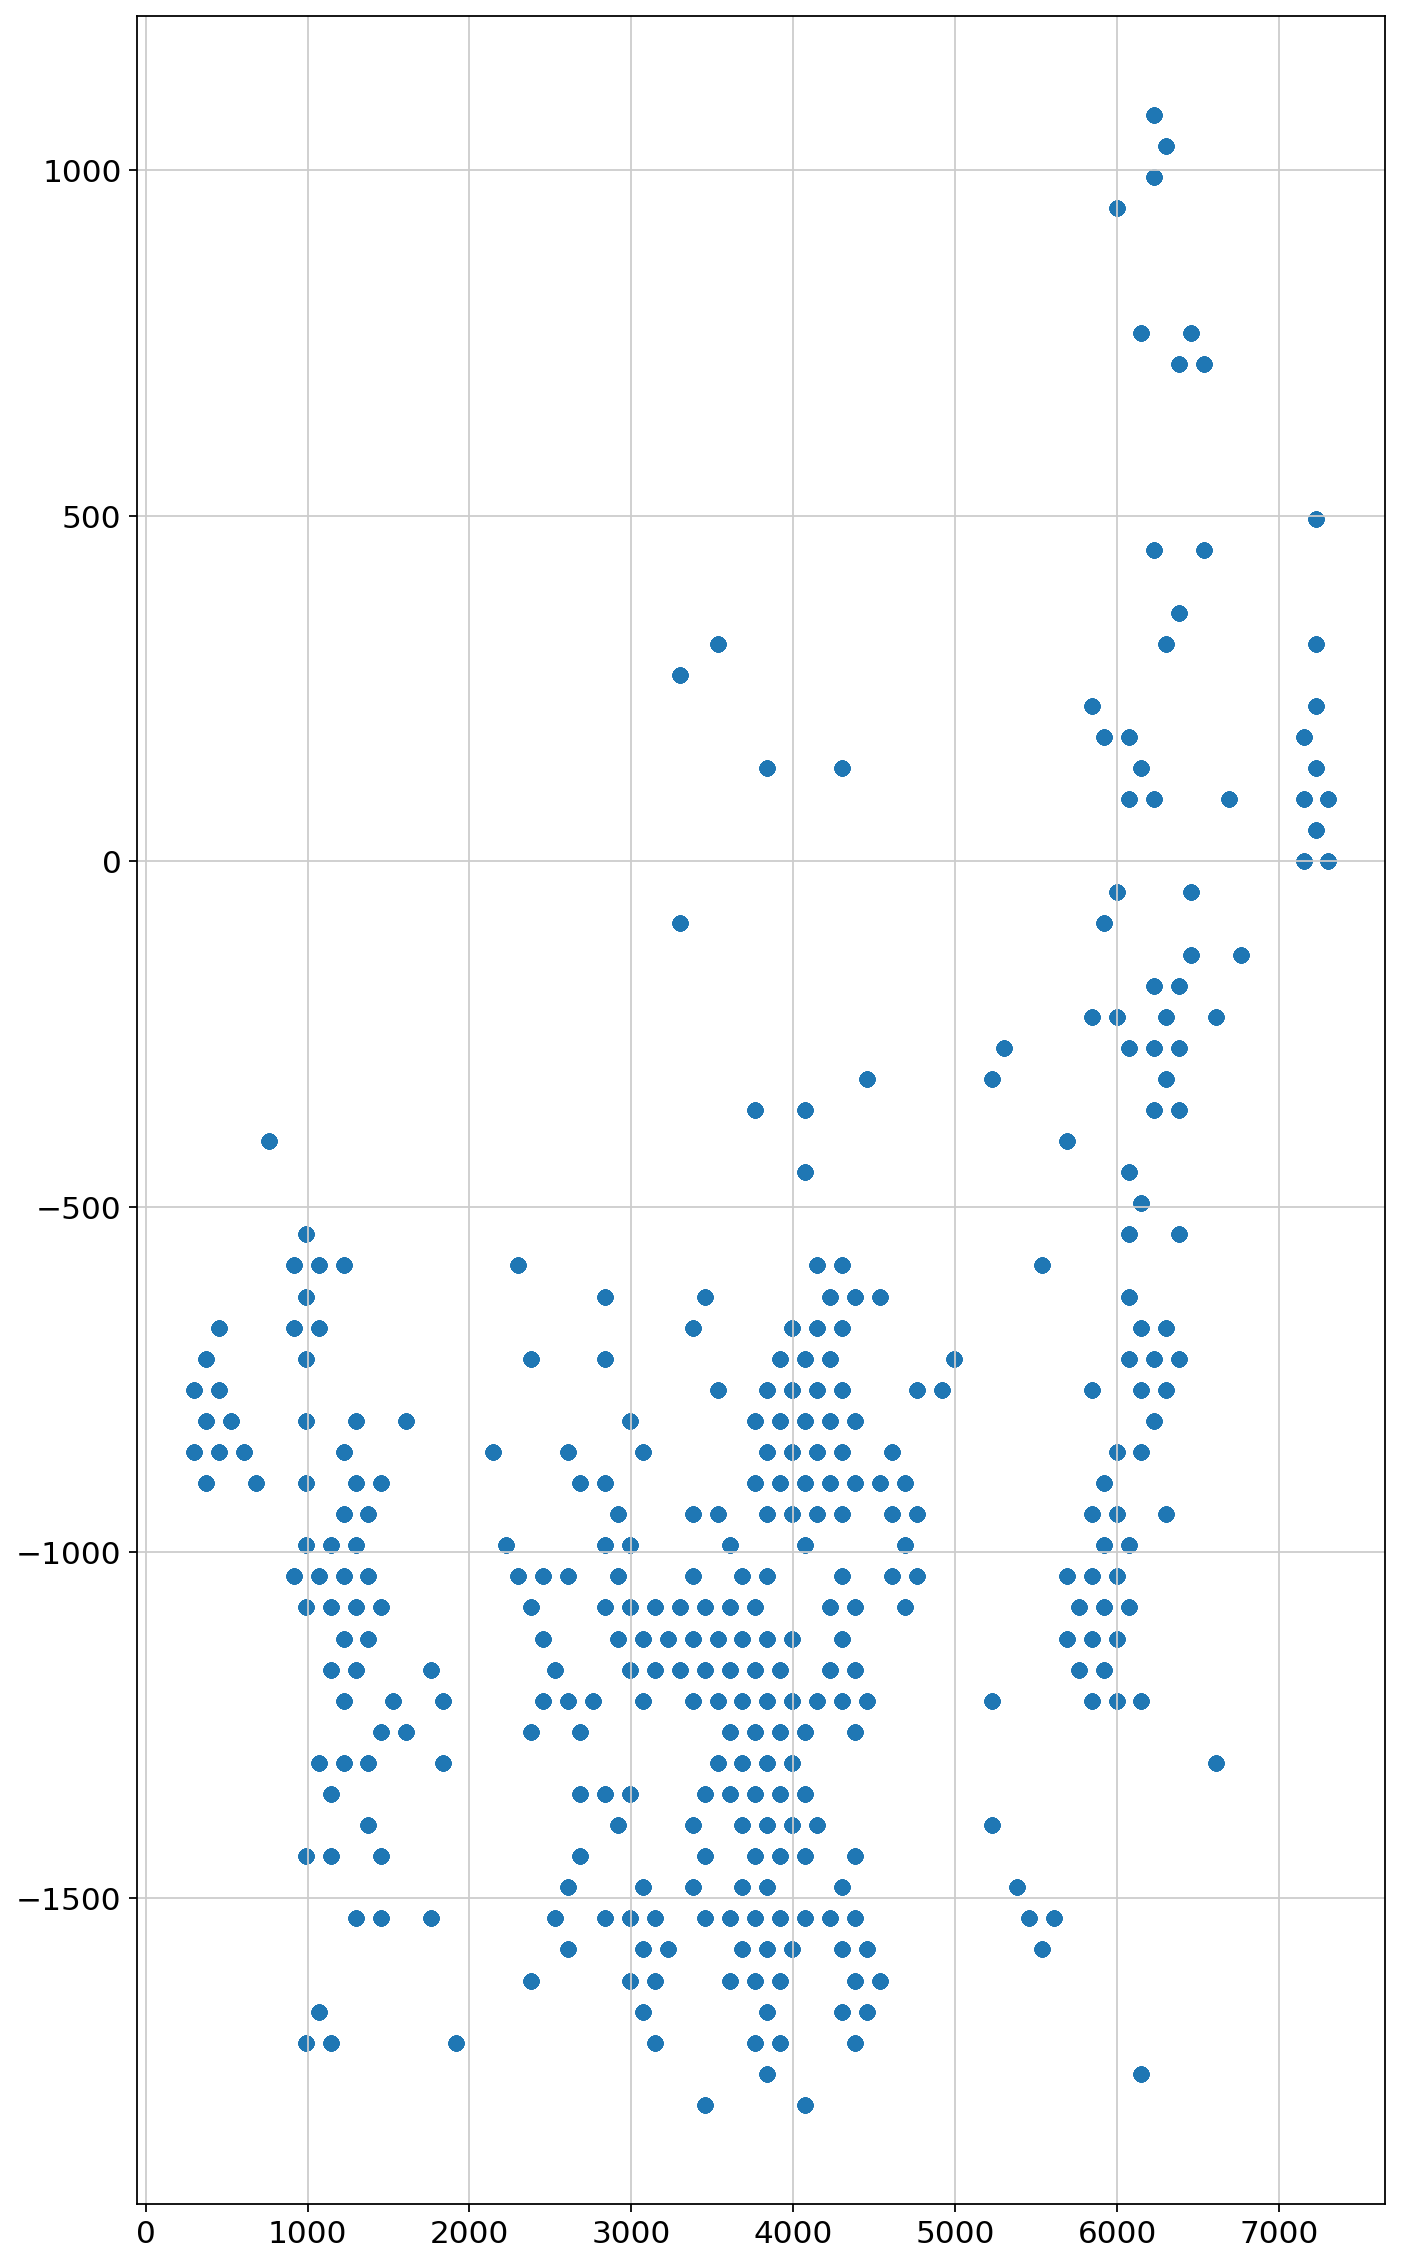

In [50]:
fig,ax = plt.subplots(figsize=(10,18))
ax.scatter(x=filted_df.iloc[:,2],y=filted_df.iloc[:,3])
plt.show()

Simulate the generation of spatial transcriptome array data, and generate a map matrix and save it in uns['density']

In [51]:
DataDir="./data/ahz8_new/"
sc_file_path = DataDir+'scRNA.h5ad'
RNA_data_adata = sc.read_h5ad(sc_file_path)

Spatial_file = DataDir + 'Insitu_count8.txt'
location_file = DataDir + 'Locations8.txt'
Spatial_data_adata = sc.read(Spatial_file, sep = '\t')
locations = pd.read_csv(location_file,sep='\t')
Spatial_data_adata.obs=locations

# # DataDir="./method/datasets/SeqFISH+/"
# sc_file_path = DataDir+'scRNA.h5ad'
# st_file_path = DataDir+'ST_10000.h5ad'
# RNA_data_adata = sc.read_h5ad(sc_file_path)
# RNA_data_adata.obs['celltype']=RNA_data_adata.obs['cell_types']
# Spatial_data_adata = sc.read_h5ad(st_file_path)

# intersect = np.intersect1d(RNA_data_adata.var_names, Spatial_data_adata.var_names)
new_sc_adata=RNA_data_adata.copy()
#sc.pp.normalize_total(new_sc_adata)
st_X=np.zeros((len(cell2spots),new_sc_adata.X.shape[1]))
spots_name=[i for i in range(len(cell2spots))]
map_matrix=pd.DataFrame(np.zeros((len(cell2spots),len(new_sc_adata.obs["celltype"].unique()))),
                        index=spots_name, columns=new_sc_adata.obs["celltype"].unique())


spots_x=[]
spots_y=[]
for i,idx in enumerate(cell2spots):
    st_X[i,:]=new_sc_adata.X[idx,:].sum(0)
    spots_x.append(filted_df["x"].loc[filted_df["index"]==idx[0]].values[0])
    spots_y.append(filted_df["y"].loc[filted_df["index"]==idx[0]].values[0])
    for j in idx:
        map_matrix.loc[spots_name[i],filted_df["celltype"].loc[filted_df["index"]==j]] += 1

st_data_obs=pd.DataFrame(index=spots_name)
st_data_obs["X"]=spots_x
st_data_obs["Y"]=spots_y
new_st_adata=sc.AnnData(st_X,obs=st_data_obs,var=new_sc_adata.var)
new_st_adata.uns['density']=map_matrix

In [52]:
print(new_st_adata)
print(new_st_adata.obs)

AnnData object with n_obs × n_vars = 360 × 34041
    obs: 'X', 'Y'
    uns: 'density'
        X    Y
0     298 -855
1     298 -765
2     375 -900
3     375 -810
4     375 -720
..    ...  ...
355  7228  225
356  7228  315
357  7228  495
358  7305    0
359  7305   90

[360 rows x 2 columns]


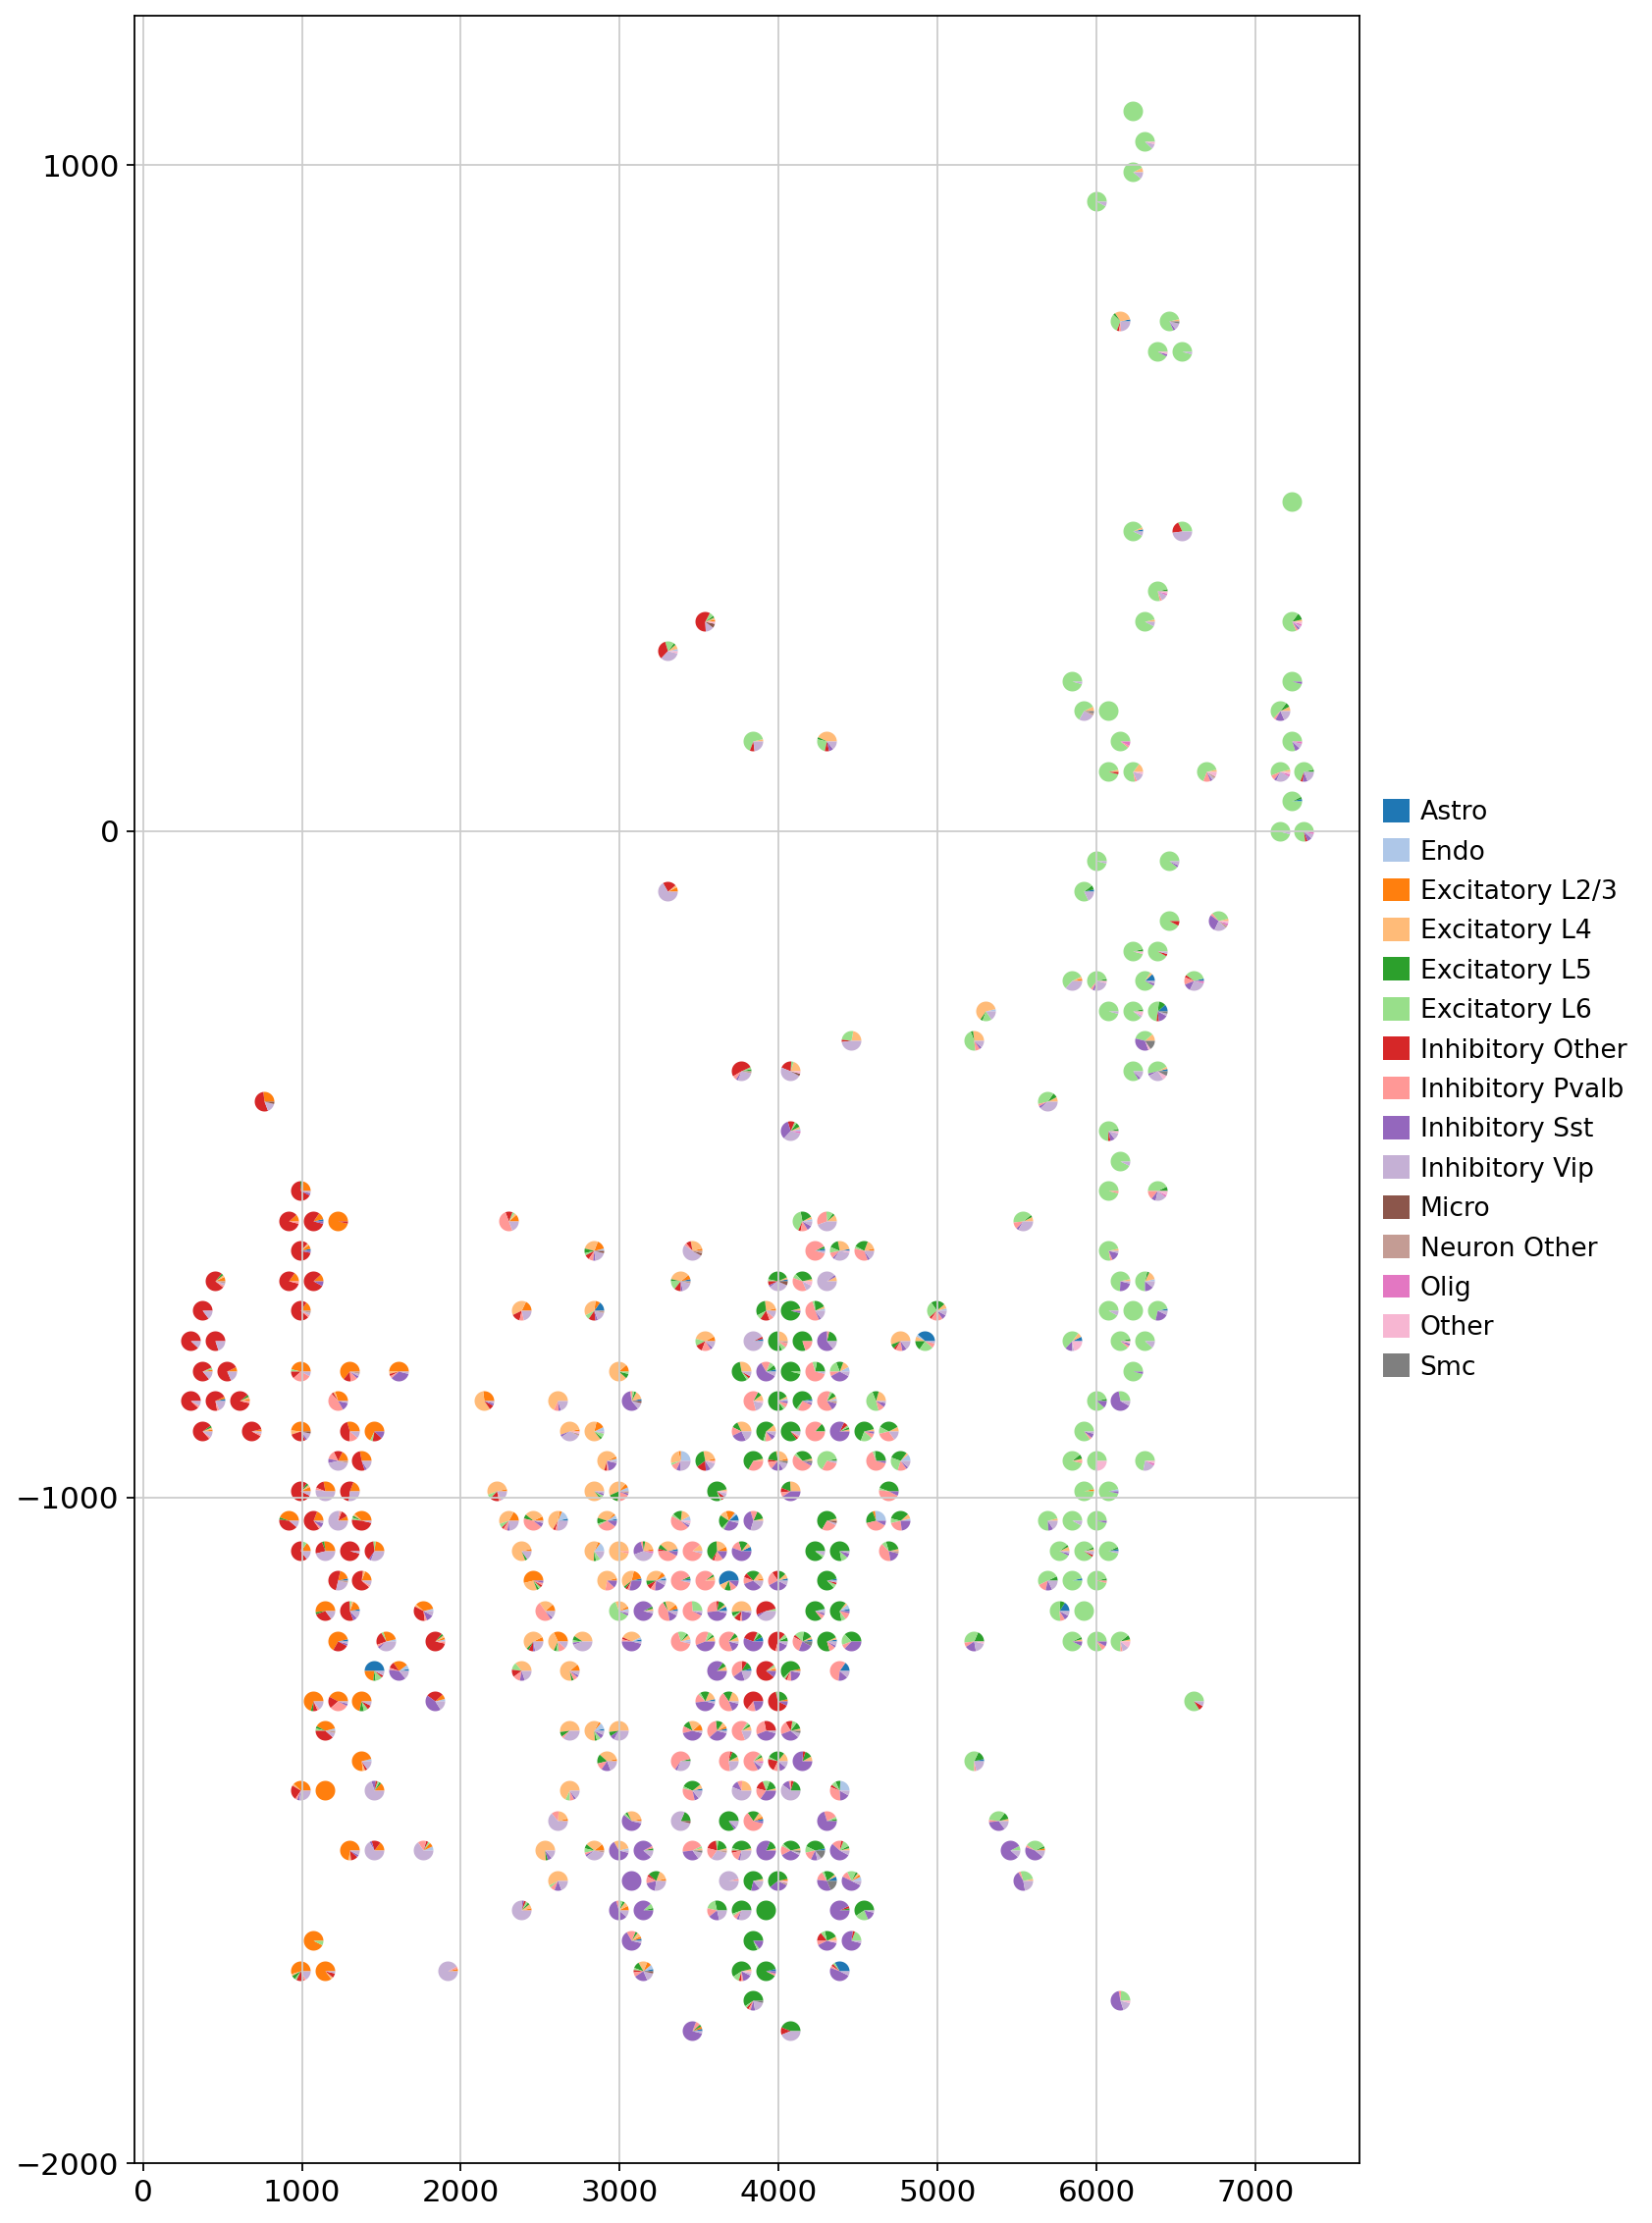

In [53]:
st_deconv_df = map_matrix.copy()
st_deconv_df = (st_deconv_df.T/st_deconv_df.sum(axis=1)).T
st_deconv_df = st_deconv_df.loc[:,np.unique(st_deconv_df.columns)]
st_deconv_df = st_deconv_df.fillna(0)
st_loc_df=new_st_adata.obs.copy()

import matplotlib.patches as mpatches

def PieMarker(loc_list, frac_list, size, color_list):
    '''
    Return marker list for a point
    '''
    frac_cumsum = np.cumsum(frac_list)
    frac_cumsum = frac_cumsum/frac_cumsum[-1]
    marker_list = []
    previous = 0
    # calculate the points of the pie pieces
    for color, frac in zip(color_list, frac_cumsum):
        curr = frac
        x  = np.cos(2 * np.pi * np.linspace(previous, curr, 50)).tolist()
        y  = np.sin(2 * np.pi * np.linspace(previous, curr, 50)).tolist()
        xy = np.row_stack([[0, 0], np.column_stack([x, y])])
        marker_list.append({'marker': xy, 's': size*np.abs(xy).max()**2, 'facecolor': color, 'edgecolor': "darkgrey", 'linewidth': 0.0001})
        previous = frac
    # scatter each of the pie pieces to create pies
    point_marker_list = []
    for marker in marker_list:
        point_marker_list.append(loc_list + [marker])
    return(point_marker_list)

DefaulfColorPalette = [
    "#1F77B4", "#AEC7E8", "#FF7F0E", "#FFBB78", "#2CA02C", "#98DF8A",
    "#D62728", "#FF9896", "#9467BD", "#C5B0D5", "#8C564B", "#C49C94",
    "#E377C2", "#F7B6D2", "#7F7F7F", "#FF9DA6", "#778AAE", "#1B9E77",
    "#A6761D", "#526A83", "#B82E2E", "#80B1D3", "#68855C", "#D95F02",
    "#BEBADA", "#AF6458", "#D9AF6B", "#9C9C5E", "#625377", "#8C785D",
    "#88CCEE", "#E73F74", "#FFFFB3", "#CCEBC5", "#332288", "#A65628"
]
color_pal = DefaulfColorPalette

pt_size=9

fig = plt.figure(figsize=(10,18))
ax = fig.add_subplot()
for i in st_deconv_df.index:
    deconv_list = st_deconv_df.iloc[i,:]
    loc_list = st_loc_df.iloc[i,:].tolist()
    point_marker_list = PieMarker(loc_list[0:2], deconv_list, pt_size**2, color_pal)
    for point_marker in point_marker_list:
        ax.scatter(point_marker[0], point_marker[1], **point_marker[-1])
# add legends
celltypes = st_deconv_df.columns
patch_list = []
for i in range(len(celltypes)):
    patch_list.append(mpatches.Patch(facecolor = color_pal[i], label = celltypes[i], edgecolor = "darkgrey", linewidth=0.001))
ax.legend(handles = patch_list, loc='center left', bbox_to_anchor=(1, 0.5), fontsize = '12', frameon = False,
    handlelength=1, handleheight=1)
# ax.axis('equal')
# ax.set_xlabel(st_loc_df.columns[0])
# ax.set_ylabel(st_loc_df.columns[1])
#ax.set_title(out_prefix, pad = 15)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
plt.yticks(np.arange(-2000,2000,1000))
plt.xticks(np.arange(0,8000,1000))
# save figure
plot_file = os.path.join(DataDir+"portion_simu2.pdf")
fig.savefig(plot_file,dpi=600,bbox_inches = "tight")
plt.show(fig)

In [54]:
# DataDir="./test/dataset12/"
sp_file_path = DataDir+'Pseudo8(15-25).h5ad'
new_st_adata.write(sp_file_path)

In [41]:
print(map_matrix.sum(1))

0       15.0
1       15.0
2       15.0
3       15.0
4       15.0
        ... 
1028    15.0
1029    11.0
1030    10.0
1031     5.0
1032     9.0
Length: 1033, dtype: float64


In [53]:
print(new_st_adata.uns['density'])

      Inhibitory Vip  Inhibitory Other  Inhibitory Sst  Inhibitory Pvalb  \
0                0.0              11.0             0.0               0.0   
1                0.0              11.0             0.0               0.0   
2                0.0               7.0             1.0               0.0   
3                0.0               3.0             0.0               0.0   
4                0.0               6.0             0.0               0.0   
...              ...               ...             ...               ...   
1027             0.0               0.0             0.0               0.0   
1028             0.0               0.0             0.0               0.0   
1029             0.0               0.0             0.0               0.0   
1030             0.0               0.0             0.0               0.0   
1031             0.0               0.0             0.0               0.0   

      Endo  Other  Excitatory L6  Excitatory L2/3  Neuron Other  \
0      0.0    0.0   

In [76]:
spatial = DataDir+'Spatial12-1.h5ad'
Spatial_adata = sc.read_h5ad(spatial)
print(Spatial_adata)
spatial2 = DataDir+'Spatial12.h5ad'
Spatial_adata2 = sc.read_h5ad(spatial2)
print(Spatial_adata2)
spatial3 = DataDir+'Spatial.h5ad'
Spatial_adata3 = sc.read_h5ad(spatial3)
print(Spatial_adata3)

AnnData object with n_obs × n_vars = 1183 × 34041
    obs: 'X', 'Y'
    uns: 'density'
AnnData object with n_obs × n_vars = 1150 × 34041
    obs: 'X', 'Y'
    uns: 'density'
AnnData object with n_obs × n_vars = 1179 × 34041
    obs: 'X', 'Y', 'n_genes'
    var: 'n_cells'
    uns: 'density'


In [51]:
sc_file=DataDir+'starmap_spatial.h5ad'
sc_file2=DataDir+'deconv_sc_rna.h5ad'
Scdata = sc.read_h5ad(sc_file)
Scdata2 = sc.read_h5ad(sc_file2)
print(Scdata.obs)
print(Scdata2.obs)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[189 rows x 0 columns]
          Cluster          celltype
cell0           0      ExcitatoryL4
cell1           1  ExcitatoryL2and3
cell2           2      ExcitatoryL6
cell3           0      ExcitatoryL4
cell4           0      ExcitatoryL4
...           ...               ...
cell1518       10              Olig
cell1519       10              Olig
cell1520        2      ExcitatoryL6
cell1521        1  ExcitatoryL2and3
cell1522        1  ExcitatoryL2and3

[1523 rows x 2 columns]
